# Microstructure Model — 5-Quantile Regression (1H)

**Architecture:** 5 quantile models (Q10, Q25, Q50, Q75, Q90) predicting 1H return distribution.

- **Q50 sign** = predicted direction (UP/DOWN)
- **Q50 magnitude** = expected move size
- **Q10-Q90 spread** = uncertainty → confidence filter
- **Trade when:** |Q50| > spread AND Q10/Q90 agree on sign (both positive or both negative)
- **EV = predicted PnL - spread_cost**
- **Validation:** Walk-forward on training set. Test set genuinely unseen.
- **NO LEAKAGE:** All thresholds computed from training data only.

In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_DIR = Path('../backend/data/features_2')
MODELS_DIR   = Path('../backend/models_5')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_NAMES = ['Q10', 'Q25', 'Q50', 'Q75', 'Q90']

# -- CRITICAL: Training cutoff --
TRAIN_END = '2024-06-30'
AVG_SPREAD = 0.00028

print('Ready.')
print(f'Models to train: {len(QUANTILES)} quantile models (1H horizon)')
print(f'Training cutoff: {TRAIN_END}')

Ready.
Models to train: 5 quantile models (1H horizon)
Training cutoff: 2024-06-30


## 1. Load Microstructure Dataset

In [15]:
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_microstructure.parquet')

label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = 'label_1H'

# Split
df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

print(f'Full dataset:  {df.shape}  ({df.index.min().date()} to {df.index.max().date()})')
print(f'Features:      {len(feature_cols)}')
print(f'Train set:     {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test set:      {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'Pairs:         {df["pair"].unique()}')
print(f'\nTarget stats (train):')
print(df_train[TARGET_COL].describe())
print(f'\nSanity: "abs_return" in feature_cols = {"abs_return" in feature_cols}')

Full dataset:  (702117, 67)  (2009-09-25 to 2025-12-31)
Features:      64
Train set:     637,166 rows  (2009-09-25 to 2024-06-28)
Test set:      64,951 rows  (2024-06-30 to 2025-12-31)
Pairs:         <ArrowStringArray>
['EURUSD', 'USDCHF', 'USDCAD', 'NZDUSD', 'GBPUSD', 'AUDUSD', 'USDJPY']
Length: 7, dtype: str

Target stats (train):
count    620852.000000
mean         -0.000003
std           0.001388
min          -0.132269
25%          -0.000523
50%           0.000000
75%           0.000527
max           0.092512
Name: label_1H, dtype: float64

Sanity: "abs_return" in feature_cols = False


## 2. Walk-Forward Splits

In [16]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits. All within training data."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df_train))
print(f'Walk-forward splits: {len(splits)} (all within training set, before {TRAIN_END})')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train -> {df_train.index[train_idx[-1]].date()} ({len(train_idx):,}) | '
          f'Test {df_train.index[test_idx[0]].date()} -> {df_train.index[test_idx[-1]].date()} ({len(test_idx):,})')

Walk-forward splits: 5 (all within training set, before 2024-06-30)
  Fold 1: Train -> 2017-01-31 (318,583) | Test 2017-01-31 -> 2018-07-18 (63,716)
  Fold 2: Train -> 2018-07-18 (382,299) | Test 2018-07-18 -> 2020-01-16 (63,716)
  Fold 3: Train -> 2020-01-16 (446,015) | Test 2020-01-16 -> 2021-08-03 (63,716)
  Fold 4: Train -> 2021-08-03 (509,731) | Test 2021-08-03 -> 2023-01-13 (63,716)
  Fold 5: Train -> 2023-01-13 (573,447) | Test 2023-01-13 -> 2024-06-28 (63,716)


## 3. LightGBM Quantile Config

In [17]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      5000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device':            'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


## 4. Train 5 Quantile Models (Walk-Forward CV + Final)

In [18]:
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]

print(f'Training samples: {len(X_clean):,} (all before {TRAIN_END})')
print(f'Target mean: {y_clean.mean():.6f}, std: {y_clean.std():.6f}')

splits = walk_forward_splits(len(X_clean))
oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
best_iters = {q: [] for q in QUANTILES}
cv_pinball = {q: [] for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'\nTraining {q_name} (alpha={q})...')
    params = get_lgbm_params(q)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        preds = model.predict(X_te)
        oof_preds[q][test_idx] = preds
        cv_pinball[q].append(mean_pinball_loss(y_te, preds, alpha=q))
        best_iters[q].append(model.best_iteration_)

    print(f'  CV Pinball: {np.mean(cv_pinball[q]):.6f} | Best iters: {best_iters[q]}')
    del model; gc.collect()

# Train final models on ALL training data
print(f'\n{"="*55}')
print('Training final models on full training set...')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    avg_iter = max(50, int(np.mean(best_iters[q])))
    params = get_lgbm_params(q)
    final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
    final_model.fit(X_clean, y_clean)

    q_int = int(q * 100)
    joblib.dump({
        'model': final_model,
        'quantile': q,
        'horizon': '1H',
        'feature_cols': feature_cols,
        'train_end': TRAIN_END,
        'avg_spread': AVG_SPREAD,
        'cv_pinball': np.mean(cv_pinball[q]),
        'n_iters': avg_iter,
    }, MODELS_DIR / f'model_1H_Q{q_int}.joblib')

    size_mb = (MODELS_DIR / f'model_1H_Q{q_int}.joblib').stat().st_size / 1024 / 1024
    print(f'  {q_name}: {avg_iter} iters, pinball={np.mean(cv_pinball[q]):.6f}, saved ({size_mb:.1f} MB)')
    del final_model; gc.collect()

print(f'\nAll 5 models saved to {MODELS_DIR}')

Training samples: 620,852 (all before 2024-06-30)
Target mean: -0.000003, std: 0.001388

Training Q10 (alpha=0.1)...
  CV Pinball: 0.000196 | Best iters: [216, 511, 54, 540, 688]

Training Q25 (alpha=0.25)...
  CV Pinball: 0.000314 | Best iters: [335, 391, 41, 620, 725]

Training Q50 (alpha=0.5)...
  CV Pinball: 0.000375 | Best iters: [212, 119, 166, 252, 334]

Training Q75 (alpha=0.75)...
  CV Pinball: 0.000308 | Best iters: [239, 329, 53, 544, 979]

Training Q90 (alpha=0.9)...
  CV Pinball: 0.000187 | Best iters: [425, 531, 79, 637, 771]

Training final models on full training set...
  Q10: 401 iters, pinball=0.000196, saved (2.1 MB)
  Q25: 422 iters, pinball=0.000314, saved (2.3 MB)
  Q50: 216 iters, pinball=0.000375, saved (1.2 MB)
  Q75: 428 iters, pinball=0.000308, saved (2.4 MB)
  Q90: 488 iters, pinball=0.000187, saved (2.5 MB)

All 5 models saved to ..\backend\models_5


## 5. Quantile Coverage (OOF Calibration)

OOF Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q10        0.10       0.093      -0.007  OK
Q25        0.25       0.240      -0.010  OK
Q50        0.50       0.498      -0.002  OK
Q75        0.75       0.759      +0.009  OK
Q90        0.90       0.905      +0.005  OK


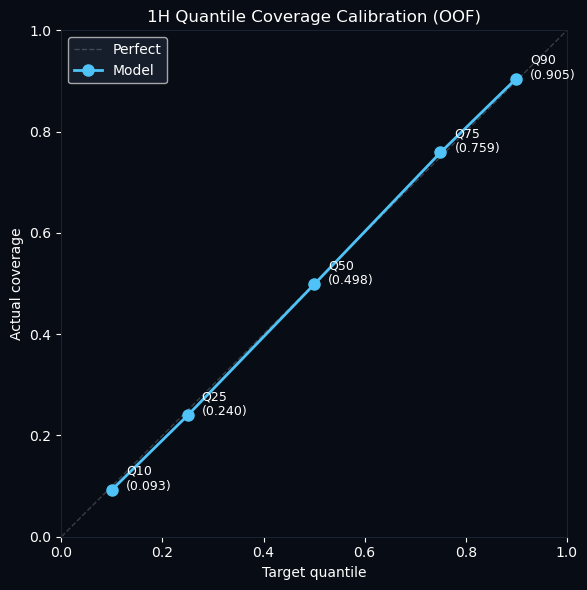

In [19]:
valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
y_oof = y_clean.values[valid_oof]

print(f'OOF Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    preds_oof = oof_preds[q][valid_oof]
    coverage  = np.mean(y_oof <= preds_oof)
    gap       = coverage - q
    flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

targets = QUANTILES
actuals = [np.mean(y_oof <= oof_preds[q][valid_oof]) for q in QUANTILES]

ax.plot([0,1], [0,1], '--', color=(1,1,1,0.2), linewidth=1, label='Perfect')
ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')
for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
    ax.annotate(f'{name}\n({a:.3f})', (t, a), textcoords='offset points',
                xytext=(10, 0), color='white', fontsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Target quantile', color='white')
ax.set_ylabel('Actual coverage', color='white')
ax.set_title('1H Quantile Coverage Calibration (OOF)', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Load final models, predict all 5 quantiles on unseen test set. Trade based on Q50 sign.

**Trading rules:**
- Direction = sign(Q50)
- Trade only when |Q50| > spread (predicted move big enough to cover costs)
- PnL per trade = direction × actual_return - spread

In [20]:
# -- Prepare test data --
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# -- Predict all 5 quantiles --
q_preds_test = {}
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    q_int = int(q * 100)
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    q_preds_test[q_name] = bundle['model'].predict(X_test_clean)
    print(f'{q_name}: mean={q_preds_test[q_name].mean():.6f}, std={q_preds_test[q_name].std():.6f}')

# -- Build results DataFrame --
results = pd.DataFrame({
    'actual_return': y_test_clean.values,
    'Q10': q_preds_test['Q10'],
    'Q25': q_preds_test['Q25'],
    'Q50': q_preds_test['Q50'],
    'Q75': q_preds_test['Q75'],
    'Q90': q_preds_test['Q90'],
    'pair': df_test.loc[valid_test, 'pair'].values,
}, index=y_test_clean.index)

results['abs_return'] = np.abs(results['actual_return'])
results['pred_dir'] = np.sign(results['Q50'])  # +1=UP, -1=DOWN
results['actual_dir'] = np.sign(results['actual_return'])
results['abs_Q50'] = np.abs(results['Q50'])
results['cone_width'] = results['Q90'] - results['Q10']  # uncertainty

print(f'\nTest set: {len(results):,} rows ({results.index.min().date()} -> {results.index.max().date()})')
print(f'Direction balance: {(results["actual_dir"] > 0).mean():.3f} UP')

# -- Evaluate with different |Q50| thresholds --
thresholds = {
    'All hours (no filter)': 0,
    '|Q50| > 0.5x spread':  AVG_SPREAD * 0.5,
    '|Q50| > 1x spread':    AVG_SPREAD,
    '|Q50| > 2x spread':    AVG_SPREAD * 2,
    '|Q50| > 3x spread':    AVG_SPREAD * 3,
    '|Q50| > 5x spread':    AVG_SPREAD * 5,
}

print(f'\n{"Filter":<25} {"Trades":>8} {"WinRate":>10} {"Avg|Move|":>12} {"EV/trade":>12} {"Total PnL":>12} {"Sharpe":>8}')
print('-' * 90)

for name, thresh in thresholds.items():
    mask = results['abs_Q50'] > thresh
    if mask.sum() < 50:
        continue
    s = results[mask]
    
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    win_rate = (s['pred_dir'] == s['actual_dir']).mean()
    avg_move = s['abs_return'].mean()
    ev = pnl.mean()
    total_pnl = pnl.sum()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    
    flag = ' <<<' if ev > 0 else ''
    print(f'{name:<25} {mask.sum():>8,} {win_rate:>9.1%} {avg_move:>12.6f} {ev:>12.6f} {total_pnl:>12.4f} {sharpe:>8.2f}{flag}')

print(f'\nSpread cost: {AVG_SPREAD:.5f}')
print('<<< = positive EV after spread')

Q10: mean=-0.001161, std=0.000536
Q25: mean=-0.000562, std=0.000279
Q50: mean=0.000003, std=0.000177
Q75: mean=0.000567, std=0.000436
Q90: mean=0.001142, std=0.000761

Test set: 63,637 rows (2024-07-01 -> 2025-12-31)
Direction balance: 0.499 UP

Filter                      Trades    WinRate    Avg|Move|     EV/trade    Total PnL   Sharpe
------------------------------------------------------------------------------------------
All hours (no filter)       63,637     51.4%     0.000785    -0.000209     -13.3202    -5.65
|Q50| > 0.5x spread          1,586     66.1%     0.002485     0.001266       2.0074     8.29 <<<
|Q50| > 1x spread              430     78.6%     0.005974     0.004979       2.1408    17.48 <<<
|Q50| > 2x spread              176     93.8%     0.012782     0.012295       2.1639    28.83 <<<
|Q50| > 3x spread              146     95.9%     0.015099     0.014651       2.1391    31.68 <<<
|Q50| > 5x spread              106     97.2%     0.019729     0.019328       2.0488    3

In [21]:
# -- Per-pair breakdown (|Q50| > 1x spread filter) --
filtered = results[results['abs_Q50'] > AVG_SPREAD]

print(f'Per-pair results (|Q50| > {AVG_SPREAD:.5f}):')
print(f'\n{"Pair":<10} {"Trades":>8} {"WinRate":>10} {"Avg|Move|":>12} {"EV/trade":>12} {"Total PnL":>12} {"Sharpe":>8}')
print('-' * 75)

for pair in sorted(filtered['pair'].unique()):
    p = filtered[filtered['pair'] == pair]
    pnl = p['pred_dir'] * p['actual_return'] - AVG_SPREAD
    win_rate = (p['pred_dir'] == p['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    flag = ' <<<' if pnl.mean() > 0 else ''
    print(f'{pair:<10} {len(p):>8,} {win_rate:>9.1%} {p["abs_return"].mean():>12.6f} {pnl.mean():>12.6f} {pnl.sum():>12.4f} {sharpe:>8.2f}{flag}')

Per-pair results (|Q50| > 0.00028):

Pair         Trades    WinRate    Avg|Move|     EV/trade    Total PnL   Sharpe
---------------------------------------------------------------------------
AUDUSD           84     84.5%     0.003365     0.002444       0.2053    33.72 <<<
EURUSD           23     69.6%     0.002627     0.001707       0.0393    27.60 <<<
GBPUSD           15     73.3%     0.001048    -0.000036      -0.0005    -1.63
NZDUSD          126     80.2%     0.007850     0.006616       0.8336    20.54 <<<
USDCAD           98     87.8%     0.011404     0.010941       1.0722    24.05 <<<
USDCHF           34     82.4%     0.001013     0.000112       0.0038     4.78 <<<
USDJPY           50     50.0%     0.001379    -0.000257      -0.0129    -9.74


## 7. Equity Curves

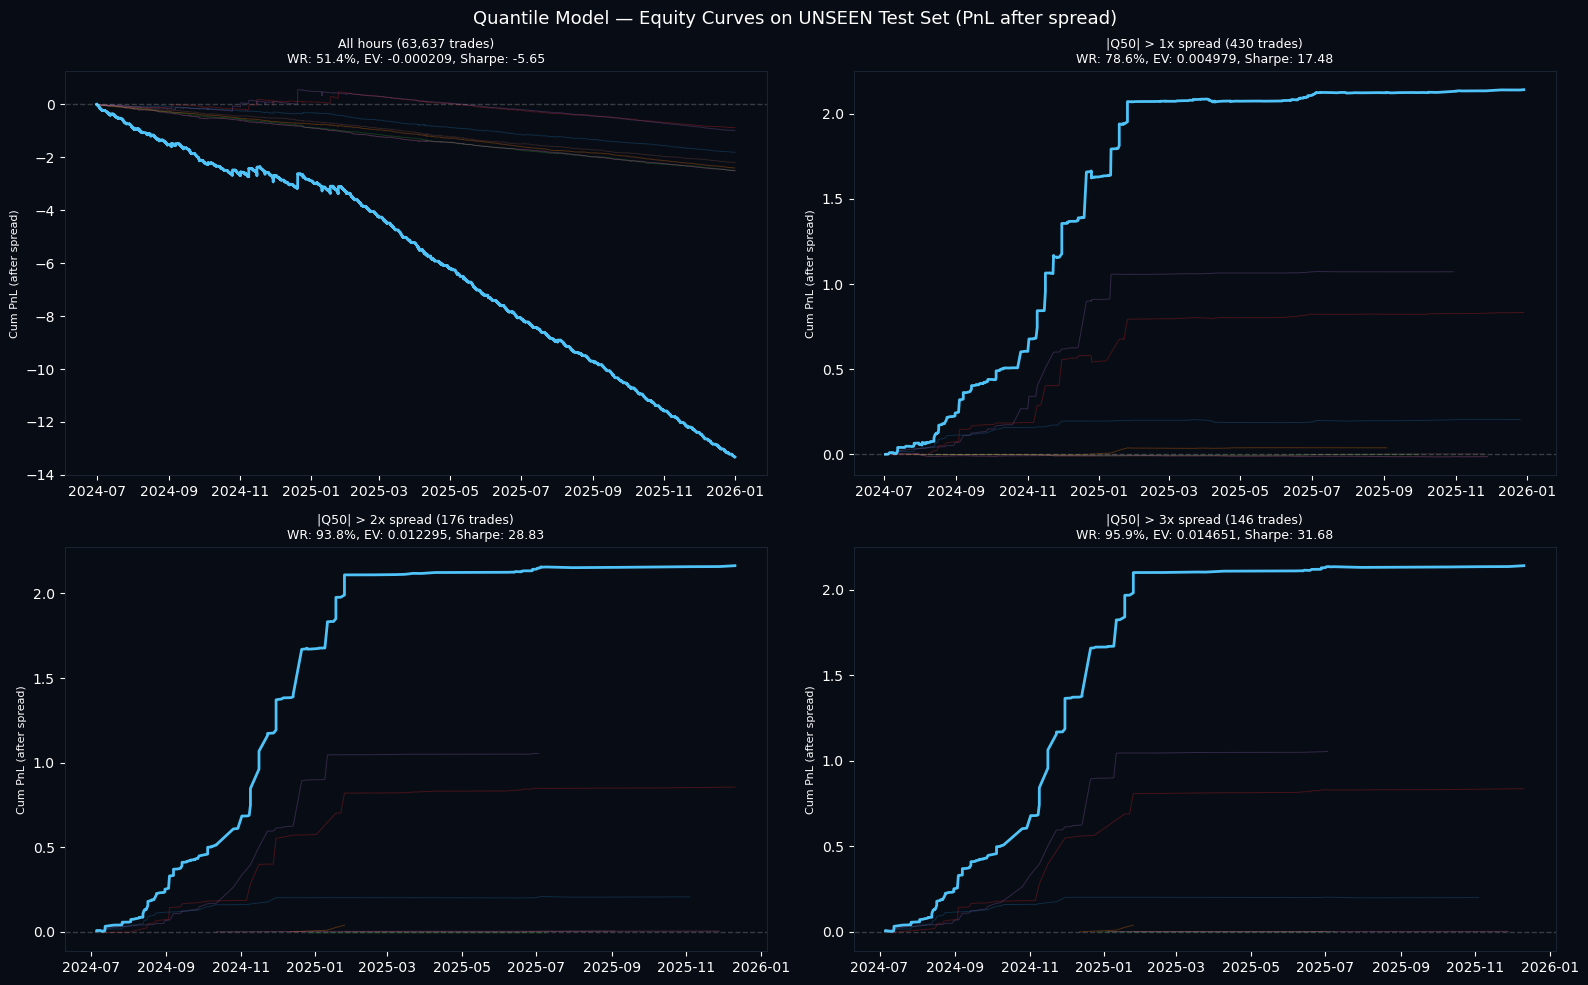

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#080c14')

strategies = {
    'All hours': results,
    f'|Q50| > 1x spread': results[results['abs_Q50'] > AVG_SPREAD],
    f'|Q50| > 2x spread': results[results['abs_Q50'] > AVG_SPREAD * 2],
    f'|Q50| > 3x spread': results[results['abs_Q50'] > AVG_SPREAD * 3],
}

for ax, (name, subset) in zip(axes.flatten(), strategies.items()):
    ax.set_facecolor('#080c14')
    
    pnl = subset['pred_dir'] * subset['actual_return'] - AVG_SPREAD
    cum_pnl = pnl.cumsum()
    
    for pair in sorted(subset['pair'].unique()):
        p = subset[subset['pair'] == pair]
        pair_pnl = (p['pred_dir'] * p['actual_return'] - AVG_SPREAD).cumsum()
        ax.plot(pair_pnl.index, pair_pnl.values, alpha=0.3, linewidth=0.7)
    
    ax.plot(cum_pnl.index, cum_pnl.values, color='#4fc3f7', linewidth=2)
    ax.axhline(0, color=(1,1,1,0.2), linewidth=1, linestyle='--')
    
    wr = (subset['pred_dir'] == subset['actual_dir']).mean()
    ev = pnl.mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    
    ax.set_title(f'{name} ({len(subset):,} trades)\nWR: {wr:.1%}, EV: {ev:.6f}, Sharpe: {sharpe:.2f}', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.set_ylabel('Cum PnL (after spread)', color='white', fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Quantile Model — Equity Curves on UNSEEN Test Set (PnL after spread)', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature Importance (Q50 model)

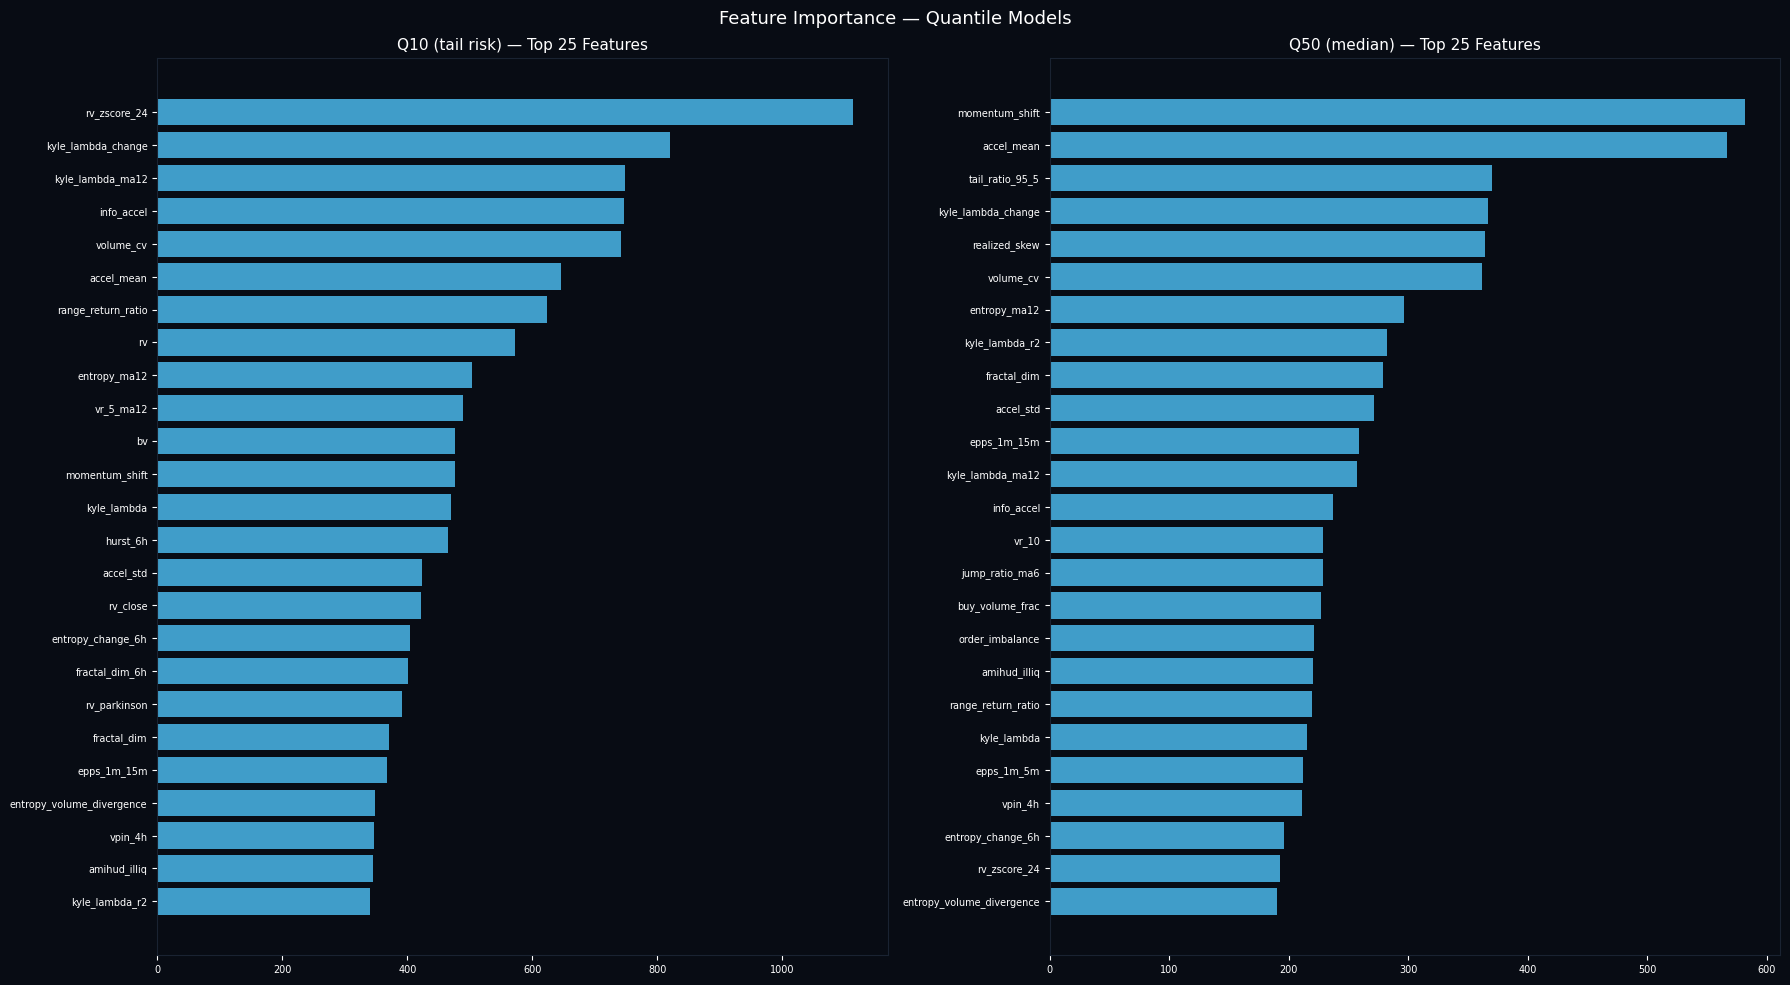

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

for ax, (q_name, q_int) in zip(axes, [('Q10 (tail risk)', 10), ('Q50 (median)', 50)]):
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(25)
    
    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    ax.set_title(f'{q_name} — Top 25 Features', color='white', fontsize=11)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance — Quantile Models', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Quantile Prediction Distribution on Test Set

Test Set Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q10        0.10       0.092      -0.008  OK
Q25        0.25       0.241      -0.009  OK
Q50        0.50       0.496      -0.004  OK
Q75        0.75       0.753      +0.003  OK
Q90        0.90       0.905      +0.005  OK


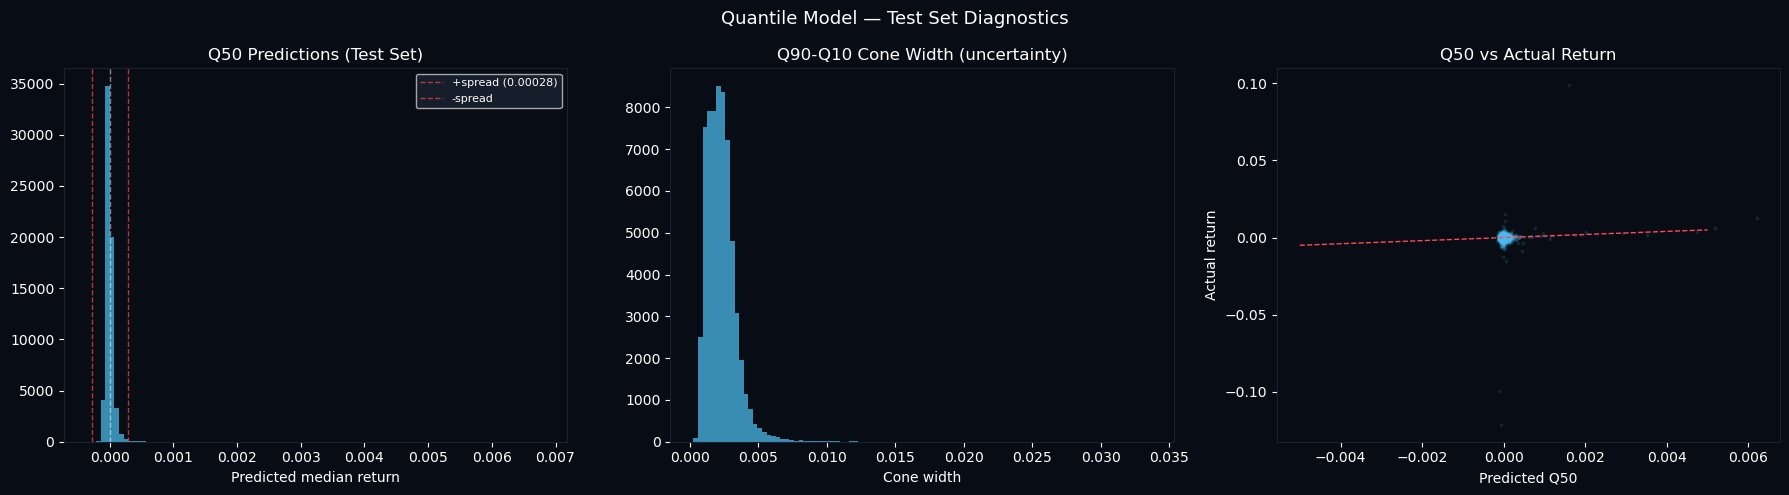

In [24]:
# Test set coverage check — are quantiles still calibrated OOS?
print('Test Set Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    coverage = (results['actual_return'] <= results[q_name]).mean()
    gap = coverage - q
    flag = 'OK' if abs(gap) < 0.03 else 'DRIFT'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Q50 prediction distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Q50 histogram
axes[0].hist(results['Q50'], bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
axes[0].axvline(AVG_SPREAD, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7, label=f'+spread ({AVG_SPREAD:.5f})')
axes[0].axvline(-AVG_SPREAD, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7, label=f'-spread')
axes[0].set_title('Q50 Predictions (Test Set)', color='white')
axes[0].set_xlabel('Predicted median return', color='white')
axes[0].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

# Cone width histogram
axes[1].hist(results['cone_width'], bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[1].set_title('Q90-Q10 Cone Width (uncertainty)', color='white')
axes[1].set_xlabel('Cone width', color='white')

# Q50 vs actual scatter (sample)
sample = results.sample(min(5000, len(results)), random_state=42)
axes[2].scatter(sample['Q50'], sample['actual_return'], alpha=0.1, s=3, color='#4fc3f7')
axes[2].plot([-0.005, 0.005], [-0.005, 0.005], '--', color='#ff4757', linewidth=1)
axes[2].set_title('Q50 vs Actual Return', color='white')
axes[2].set_xlabel('Predicted Q50', color='white')
axes[2].set_ylabel('Actual return', color='white')

plt.suptitle('Quantile Model — Test Set Diagnostics', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary

In [25]:
print('=' * 70)
print('MICROSTRUCTURE QUANTILE MODEL — TRAINING COMPLETE')
print('=' * 70)

print(f'\nModels saved to: {MODELS_DIR.resolve()}')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {f.name:<25} {f.stat().st_size / 1024 / 1024:.1f} MB')

print(f'\n-- CV Results --')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'  {q_name}: pinball={np.mean(cv_pinball[q]):.6f}, avg_iters={int(np.mean(best_iters[q]))}')

# Best config from test
print(f'\n-- Test Set Results (UNSEEN, after {TRAIN_END}) --')
best_name, best_ev, best_wr, best_sharpe = '', -999, 0, 0
for name, thresh in thresholds.items():
    mask = results['abs_Q50'] > thresh
    if mask.sum() < 50:
        continue
    s = results[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    ev = pnl.mean()
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    if ev > best_ev:
        best_name, best_ev, best_wr, best_sharpe = name, ev, wr, sharpe

print(f'  Best config:  {best_name}')
print(f'  Win rate:     {best_wr:.1%}')
print(f'  EV/trade:     {best_ev:.6f}')
print(f'  Sharpe:       {best_sharpe:.2f}')
print(f'  Spread cost:  {AVG_SPREAD:.5f}')
print(f'  EV positive:  {"YES" if best_ev > 0 else "NO"}')

print(f'\nTest period: {results.index.min().date()} -> {results.index.max().date()}')
print(f'Training cutoff: {TRAIN_END}')
print(f'Features: {len(feature_cols)} microstructure features')

MICROSTRUCTURE QUANTILE MODEL — TRAINING COMPLETE

Models saved to: C:\Users\noual\lumeny\backend\models_5
  model_1H_Q10.joblib       2.1 MB
  model_1H_Q25.joblib       2.3 MB
  model_1H_Q50.joblib       1.2 MB
  model_1H_Q75.joblib       2.4 MB
  model_1H_Q90.joblib       2.5 MB

-- CV Results --
  Q10: pinball=0.000196, avg_iters=401
  Q25: pinball=0.000314, avg_iters=422
  Q50: pinball=0.000375, avg_iters=216
  Q75: pinball=0.000308, avg_iters=428
  Q90: pinball=0.000187, avg_iters=488

-- Test Set Results (UNSEEN, after 2024-06-30) --
  Best config:  |Q50| > 5x spread
  Win rate:     97.2%
  EV/trade:     0.019328
  Sharpe:       36.75
  Spread cost:  0.00028
  EV positive:  YES

Test period: 2024-07-01 -> 2025-12-31
Training cutoff: 2024-06-30
Features: 64 microstructure features
